# TrueRender v4 — Clean Mesh First Pipeline

v1/v2/v3 proved that recovering a final object mesh from 2DGS TSDF or SuGaR outputs is unreliable for this Hydro Flask video: both outputs contain object signal, but also many floaters and fragments.

v4 changes the goal: produce a clean, watertight final object mesh with little or no manual cleanup. The main path uses the video only to select a high-quality, SAM-masked object image, then runs an image-to-3D mesh model that is designed to output a coherent object asset.

Preferred model path:

1. Extract/select best frames from the phone video
2. Segment the Hydro Flask with SAM masks
3. Choose the best masked canonical frame
4. Run Stable Fast 3D (SF3D) to generate textured GLB
5. If SF3D is unavailable, run TripoSR fallback to generate OBJ/mesh
6. Validate the output mesh and save final assets

This intentionally avoids TSDF mesh fusion from splats.

## Runtime Dependency Baseline

Run this as the first code cell in a fresh Colab runtime. If you see `numpy.dtype size changed`, use **Runtime → Disconnect and delete runtime**, reconnect, then run v4 from the top. That error means NumPy was changed underneath already-loaded binary packages.

In [1]:
# Establish a stable NumPy/OpenCV baseline before importing cv2, SAM, or image-to-3D packages.
# Colab may preload NumPy before your first visible cell. If the wrong NumPy is already loaded,
# this cell installs the pinned stack and restarts the Python kernel once. Then rerun from the top.
import os
import sys
import subprocess

TARGET_NUMPY = "1.26.4"
BASELINE_PACKAGES = [
    "numpy==1.26.4",
    "opencv-python-headless==4.10.0.84",
    "pillow",
]


def install_baseline():
    subprocess.run([
        "python", "-m", "pip", "install", "-q", "--upgrade", "--force-reinstall",
        *BASELINE_PACKAGES,
    ], check=True)


if "numpy" in sys.modules:
    import numpy as _np
    if _np.__version__ != TARGET_NUMPY:
        print(f"NumPy is already loaded as {_np.__version__}; installing pinned baseline and restarting kernel once...")
        install_baseline()
        print("Installed baseline. Runtime will restart now. After it reconnects, rerun from the top.")
        os.kill(os.getpid(), 9)
    print(f"NumPy already imported with compatible version {_np.__version__}; continuing.")
else:
    install_baseline()
    print("Dependency baseline installed: numpy==1.26.4, opencv-python-headless==4.10.0.84")

NumPy already imported with compatible version 1.26.4; continuing.


In [2]:
# Global configuration
import os
import glob
import json
import time
import shutil
import subprocess
from pathlib import Path

import numpy as np
from PIL import Image, ImageOps

DRIVE_ROOT = "/content/drive/MyDrive"
VIDEO_PATH = f"{DRIVE_ROOT}/hydroflaskgreen.MOV"

FRAMES_RAW = "/content/frames_raw_v4"
FRAMES_KEEP = "/content/frames_v4"
SAM_INPUT = "/content/sam3_input_v4"
MASKS_DIR = "/content/masks_v4"
FRAMES_RGBA = "/content/frames_rgba_v4"
CANONICAL_DIR = "/content/canonical_v4"
OUTPUT_DIR = "/content/outputs_v4"

DRIVE_FRAMES = f"{DRIVE_ROOT}/truerender_frames_v4"
DRIVE_MASKS = f"{DRIVE_ROOT}/truerender_masks_v4"
DRIVE_RGBA = f"{DRIVE_ROOT}/truerender_rgba_frames_v4"
DRIVE_CANONICAL = f"{DRIVE_ROOT}/truerender_canonical_v4"
DRIVE_FINAL = f"{DRIVE_ROOT}/truerender_final_v4"

N_KEEP = 60
FPS = 6
USE_CHECKPOINTS = True

for d in [FRAMES_RAW, FRAMES_KEEP, SAM_INPUT, MASKS_DIR, FRAMES_RGBA, CANONICAL_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

print("TrueRender v4 config ready")

TrueRender v4 config ready


In [4]:
from google.colab import drive

drive.mount("/content/drive")

# Optional HF token prompt. Required for gated models such as Stable Fast 3D.
import getpass

if not os.environ.get("HF_TOKEN"):
    hf_token = getpass.getpass("HF_TOKEN for Hugging Face downloads (optional, hidden): ").strip()
    if hf_token:
        os.environ["HF_TOKEN"] = hf_token
        os.environ["HUGGING_FACE_HUB_TOKEN"] = hf_token
        print("HF_TOKEN set for this runtime")
    else:
        print("Continuing without HF_TOKEN")
else:
    print("HF_TOKEN already set")


def reset_dir(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)


def copytree_fresh(src, dst):
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(src, dst)


def restore_checkpoint(src, dst, label):
    if USE_CHECKPOINTS and os.path.exists(src):
        reset_dir(dst)
        for item in sorted(os.listdir(src)):
            s = os.path.join(src, item)
            d = os.path.join(dst, item)
            if os.path.isdir(s):
                shutil.copytree(s, d)
            else:
                shutil.copy2(s, d)
        print(f"Restored {label}: {len(os.listdir(dst))} files")
        return True
    return False


def assert_nonempty_dir(path, label):
    files = sorted(os.listdir(path)) if os.path.exists(path) else []
    assert files, f"{label} missing or empty: {path}"
    return files

print("Drive/helpers ready")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
HF_TOKEN already set
Drive/helpers ready


## Stage 1 — Extract More Candidate Frames

v4 keeps more frames than v3 because the goal is to choose the cleanest single image for object-to-3D generation. We still use Laplacian sharpness, but we keep `N_KEEP=60` candidates so the selection stage has better choices.

In [5]:
import cv2

if not restore_checkpoint(DRIVE_FRAMES, FRAMES_KEEP, "candidate frames"):
    assert os.path.exists(VIDEO_PATH), f"Video not found: {VIDEO_PATH}"
    reset_dir(FRAMES_RAW)
    reset_dir(FRAMES_KEEP)

    t0 = time.time()
    subprocess.run([
        "ffmpeg", "-y", "-i", VIDEO_PATH,
        "-vf", f"fps={FPS}",
        f"{FRAMES_RAW}/frame_%05d.jpg",
    ], check=True)

    scored = []
    for path in sorted(glob.glob(f"{FRAMES_RAW}/*.jpg")):
        gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        score = cv2.Laplacian(gray, cv2.CV_64F).var()
        scored.append((path, score))

    keep = sorted([p for p, _ in sorted(scored, key=lambda x: x[1], reverse=True)[:N_KEEP]])
    for dst_idx, src in enumerate(keep):
        shutil.copy2(src, f"{FRAMES_KEEP}/frame_{dst_idx:05d}.jpg")

    copytree_fresh(FRAMES_KEEP, DRIVE_FRAMES)
    print(f"Kept {len(keep)} / {len(scored)} candidate frames in {time.time() - t0:.1f}s")

frames = assert_nonempty_dir(FRAMES_KEEP, "candidate frames")
print(f"Candidate frames: {len(frames)}")

Restored candidate frames: 60 files
Candidate frames: 60


## Stage 2 — Segment Object With SAM 3

Reuse the proven v3 strategy: SAM masks become real alpha channels. For v4, these masks are used to choose a clean single-image input for the mesh model.

In [6]:
# Install SAM 3
os.chdir("/content")
if not os.path.exists("/content/sam3"):
    subprocess.run(["git", "clone", "--quiet", "https://github.com/facebookresearch/sam3.git"], check=True)
os.chdir("/content/sam3")
subprocess.run(["python", "-m", "pip", "install", "-q", "-e", "."], check=True)
print("SAM 3 ready")

SAM 3 ready


In [7]:
import cv2

SAM_PROMPT = "green hydroflask water bottle"

if restore_checkpoint(DRIVE_MASKS, MASKS_DIR, "SAM masks") and restore_checkpoint(DRIVE_RGBA, FRAMES_RGBA, "RGBA frames"):
    print("Using saved SAM outputs")
else:
    reset_dir(SAM_INPUT)
    reset_dir(MASKS_DIR)
    reset_dir(FRAMES_RGBA)

    orig_frames = sorted(os.listdir(FRAMES_KEEP))
    for i, fname in enumerate(orig_frames):
        shutil.copy2(f"{FRAMES_KEEP}/{fname}", f"{SAM_INPUT}/{i}.jpg")

    from sam3.model_builder import build_sam3_video_predictor

    pred = build_sam3_video_predictor()
    resp = pred.handle_request(dict(type="start_session", resource_path=SAM_INPUT))
    sid = resp["session_id"]
    pred.handle_request(dict(type="add_prompt", session_id=sid, frame_index=0, text=SAM_PROMPT))

    results, skipped = [], 0
    for r in pred.propagate_in_video(sid):
        masks = r["outputs"]["out_binary_masks"]
        results.append((r["frame_index"], masks))
        if len(masks) == 0:
            skipped += 1
    pred.close_session(sid)

    assert skipped == 0, f"SAM failed on {skipped} frames; inspect prompts before continuing"

    for idx, masks in sorted(results, key=lambda x: x[0]):
        src_name = orig_frames[idx]
        stem = Path(src_name).stem
        rgb = cv2.imread(f"{FRAMES_KEEP}/{src_name}", cv2.IMREAD_COLOR)
        rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
        mask = np.asarray(masks[0]).astype(bool)
        mask_u8 = (mask.astype(np.uint8) * 255)
        kernel = np.ones((3, 3), np.uint8)
        mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_OPEN, kernel)
        mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_CLOSE, kernel)
        rgba = np.dstack([rgb, mask_u8])
        Image.fromarray(mask_u8).save(f"{MASKS_DIR}/{stem}.png")
        Image.fromarray(rgba).save(f"{FRAMES_RGBA}/{stem}.png")

    copytree_fresh(MASKS_DIR, DRIVE_MASKS)
    copytree_fresh(FRAMES_RGBA, DRIVE_RGBA)
    print(f"Saved SAM outputs for {len(results)} frames")

mask_files = assert_nonempty_dir(MASKS_DIR, "SAM masks")
rgba_files = assert_nonempty_dir(FRAMES_RGBA, "RGBA frames")
print(f"Masks: {len(mask_files)}  RGBA frames: {len(rgba_files)}")
print("Sample RGBA mode:", Image.open(f"{FRAMES_RGBA}/{rgba_files[0]}").mode)

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO 2026-04-26 02:51:49,249 915 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-04-26 02:51:49,521 915 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-04-26 02:51:49,521 915 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-04-26 02:51:58,801 915 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not aut

config.json: 0.00B [00:00, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

INFO 2026-04-26 02:52:20,963 915 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-04-26 02:52:20,964 915 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***


frame loading (image folder) [rank=0]: 100%|██████████| 60/60 [00:02<00:00, 24.16it/s]
INFO 2026-04-26 02:52:23,566 915 sam3_base_predictor.py: 134: started new session 3daf764f-60b5-4fce-8731-c8ec04760bd1


propagate_in_video:   0%|          | 0/60 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

INFO 2026-04-26 02:52:40,350 915 sam3_base_predictor.py: 293: propagation ended in session 3daf764f-60b5-4fce-8731-c8ec04760bd1
INFO 2026-04-26 02:52:40,588 915 sam3_base_predictor.py: 312: removed session 3daf764f-60b5-4fce-8731-c8ec04760bd1


Saved SAM outputs for 60 frames
Masks: 60  RGBA frames: 60
Sample RGBA mode: RGBA


## Stage 3 — Choose Canonical Object Image

Image-to-3D models work best with a centered, tightly cropped, single object on transparent or clean background. This stage scores all SAM-masked frames and chooses a canonical input image automatically.

Best canonical frame: frame_00005 score= 1.522 {'area_frac': 0.11363956404320988, 'bbox_area_frac': 0.13240933641975308, 'fill_ratio': 0.8582443437595606, 'center_penalty': 0.01846064814814813}
Saved canonical input: /content/canonical_v4/hydroflask_canonical_rgba.png


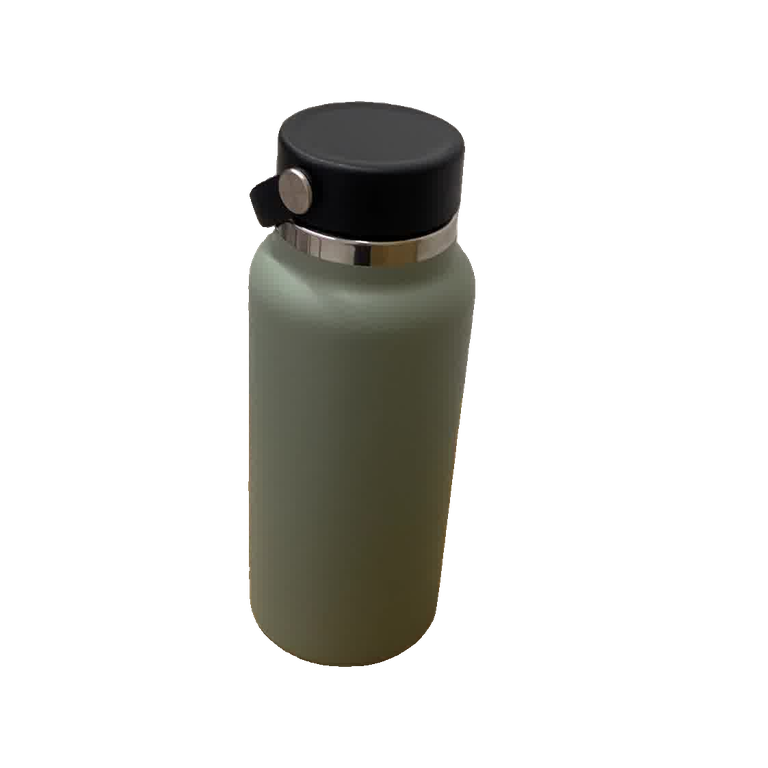

In [9]:
reset_dir(CANONICAL_DIR)

CANONICAL_SIZE = 768
MIN_MASK_AREA = 0.015
MAX_MASK_AREA = 0.70

scores = []
for mask_path in sorted(glob.glob(f"{MASKS_DIR}/*.png")):
    stem = Path(mask_path).stem
    rgba_path = f"{FRAMES_RGBA}/{stem}.png"
    mask = np.array(Image.open(mask_path).convert("L")) > 127
    if mask.sum() == 0:
        continue
    ys, xs = np.where(mask)
    h, w = mask.shape
    area_frac = mask.mean()
    if not (MIN_MASK_AREA <= area_frac <= MAX_MASK_AREA):
        continue

    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    bbox_w, bbox_h = x1 - x0 + 1, y1 - y0 + 1
    bbox_area_frac = (bbox_w * bbox_h) / (w * h)
    cx, cy = (x0 + x1) / 2 / w, (y0 + y1) / 2 / h
    center_penalty = abs(cx - 0.5) + abs(cy - 0.5)
    fill_ratio = mask.sum() / max(bbox_w * bbox_h, 1)
    size_score = -abs(bbox_area_frac - 0.25)  # prefer visible object, not tiny/not clipped
    score = 2.0 * fill_ratio + 1.5 * size_score - 1.0 * center_penalty
    scores.append((score, stem, dict(area_frac=area_frac, bbox_area_frac=bbox_area_frac, fill_ratio=fill_ratio, center_penalty=center_penalty)))

assert scores, "No usable canonical frame candidates. Inspect SAM masks."
scores = sorted(scores, reverse=True)
best_score, best_stem, best_meta = scores[0]
print("Best canonical frame:", best_stem, "score=", round(best_score, 3), best_meta)

rgba = Image.open(f"{FRAMES_RGBA}/{best_stem}.png").convert("RGBA")
mask = np.array(Image.open(f"{MASKS_DIR}/{best_stem}.png").convert("L")) > 127
ys, xs = np.where(mask)
x0, x1 = xs.min(), xs.max()
y0, y1 = ys.min(), ys.max()

# Add padding around the object, then square-crop.
pad = int(0.18 * max(x1 - x0 + 1, y1 - y0 + 1))
x0, x1 = max(0, x0 - pad), min(rgba.width - 1, x1 + pad)
y0, y1 = max(0, y0 - pad), min(rgba.height - 1, y1 + pad)
side = max(x1 - x0 + 1, y1 - y0 + 1)
cx, cy = (x0 + x1) // 2, (y0 + y1) // 2
x0 = max(0, min(rgba.width - side, cx - side // 2))
y0 = max(0, min(rgba.height - side, cy - side // 2))
x1, y1 = x0 + side, y0 + side

crop = rgba.crop((x0, y0, x1, y1))
crop = ImageOps.contain(crop, (CANONICAL_SIZE, CANONICAL_SIZE), method=Image.Resampling.LANCZOS)
canvas = Image.new("RGBA", (CANONICAL_SIZE, CANONICAL_SIZE), (255, 255, 255, 0))
canvas.alpha_composite(crop, ((CANONICAL_SIZE - crop.width) // 2, (CANONICAL_SIZE - crop.height) // 2))

canonical_png = f"{CANONICAL_DIR}/hydroflask_canonical_rgba.png"
canvas.save(canonical_png)
copytree_fresh(CANONICAL_DIR, DRIVE_CANONICAL)
print("Saved canonical input:", canonical_png)
canvas

## Stage 4A — Preferred: Stable Fast 3D

Stable Fast 3D is designed for exactly this goal: a coherent textured mesh asset from one object image. It usually produces a cleaner final object than trying to mesh splats from a noisy phone capture.

Requirements:

- GPU runtime
- Hugging Face token with access to `stabilityai/stable-fast-3d`
- Run from the canonical transparent PNG generated above

In [11]:
# Install Stable Fast 3D for comparison
# Strategy: install the minimal SF3D stack, patch out rembg for our SAM-masked RGBA input,
# and run with --remesh_option none to avoid optional remeshing dependencies.
import sys

PYTHON = sys.executable
SF3D_REPO = "/content/stable-fast-3d"
SF3D_AVAILABLE = False

os.chdir("/content")
if not os.path.exists(SF3D_REPO):
    subprocess.run(["git", "clone", "--quiet", "https://github.com/Stability-AI/stable-fast-3d", SF3D_REPO], check=True)
os.chdir(SF3D_REPO)

# Restore files before patching so the cell is idempotent.
subprocess.run(["git", "checkout", "--", "run.py", "sf3d/utils.py"], check=True)

sf3d_deps = [
    "setuptools==69.5.1",
    "wheel",
    "einops==0.7.0",
    "jaxtyping==0.2.31",
    "omegaconf==2.3.0",
    "transformers==4.42.3",
    "open_clip_torch==2.24.0",
    "trimesh==4.4.1",
    "numpy==1.26.4",
    "huggingface-hub==0.23.4",
    "safetensors",
]

install_cmds = [
    [PYTHON, "-m", "pip", "install", "-q", "--upgrade", *sf3d_deps],
    [PYTHON, "-m", "pip", "install", "-q", "./texture_baker/"],
    [PYTHON, "-m", "pip", "install", "-q", "./uv_unwrapper/"],
]

log_path = "/content/sf3d_install.log"
last_lines = []
with open(log_path, "w") as log:
    for cmd in install_cmds:
        print("Running:", " ".join(cmd))
        log.write("Running: " + " ".join(cmd) + "\n")
        proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
        for line in proc.stdout:
            print(line, end="")
            log.write(line)
            log.flush()
            last_lines.append(line)
            if len(last_lines) > 160:
                last_lines.pop(0)
        ret = proc.wait()
        if ret != 0:
            print("\nSF3D install failed.")
            print("--- Last 160 lines from SF3D install log ---")
            print("".join(last_lines))
            print(f"Full install log saved at: {log_path}")
            raise subprocess.CalledProcessError(ret, cmd)

# Patch run.py so it can accept our SAM-masked RGBA without importing/running rembg.
run_py = Path(SF3D_REPO) / "run.py"
code = run_py.read_text()
code = code.replace("import rembg\n", "# TRUERENDER_PATCH_NO_REMBG: rembg is imported lazily only when requested\nrembg = None\n", 1)
insert_after = '''parser.add_argument(
    "--foreground-ratio",
    default=0.85,
    type=float,
    help="Ratio of the foreground size to the image size. Only used when --no-remove-bg is not specified. Default: 0.85",
)'''
no_bg_arg = insert_after + '''
parser.add_argument(
    "--no-remove-bg",
    action="store_true",
    help="Use the input alpha channel directly instead of running rembg.",
)'''
if insert_after not in code:
    raise RuntimeError("Could not find foreground-ratio parser block in SF3D run.py")
code = code.replace(insert_after, no_bg_arg, 1)
code = code.replace(
    "rembg_session = rembg.new_session()",
    "rembg_session = None if args.no_remove_bg else __import__('rembg').new_session()",
    1,
)
code = code.replace(
    '''image = remove_background(
                Image.open(image_path).convert("RGBA"), rembg_session
            )
            image = resize_foreground(image, args.foreground_ratio)''',
    '''image = Image.open(image_path).convert("RGBA")
            if not args.no_remove_bg:
                image = remove_background(image, rembg_session)
            image = resize_foreground(image, args.foreground_ratio)''',
    1,
)
run_py.write_text(code)

utils_py = Path(SF3D_REPO) / "sf3d" / "utils.py"
code = utils_py.read_text()
code = code.replace("import rembg\n", "# TRUERENDER_PATCH_NO_REMBG_UTILS: rembg is imported lazily only when remove_background is called\nrembg = None\n", 1)
code = code.replace(
    "    if do_remove:\n        image = rembg.remove(image, session=rembg_session, **rembg_kwargs)",
    "    if do_remove:\n        import rembg\n        image = rembg.remove(image, session=rembg_session, **rembg_kwargs)",
    1,
)
utils_py.write_text(code)

probe = subprocess.run(
    [PYTHON, "-c", "import sys; import sf3d; print(sys.executable); print('sf3d import ok')"],
    capture_output=True,
    text=True,
    check=True,
    cwd=SF3D_REPO,
)
print("Child Python probe:\n" + probe.stdout)
SF3D_AVAILABLE = True
print("Stable Fast 3D installed and patched for SAM RGBA input")


Running: python -m pip install -r requirements.txt
Ignoring rembg: markers 'sys_platform == "darwin"' don't match your environment
Processing ./texture_baker
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
Processing ./uv_unwrapper
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached einops-0.7.0-py3-none-any.whl.metadata (13 kB)
  Using cached jaxtyping-0.2.31-py3-none-any.whl.metadata (6.4 kB)
  Using cached transformers-4.42.3-py3-none-any.whl.metadata (43 kB)
  Using cached open_clip_torch-2.24.0-py3-none-any.whl.metadata (30 kB)
  Using cached trimesh-4.4.1-py3-none-any.whl.metadata (18 kB)
  Using cached huggingface_hub-0.23.4-py3-none-any.whl.metadata (12 kB)
  Using cached rembg-2.0.57-py3-none-any.whl.metadata (16 kB)
  Using cached pynanoinstantmeshes-0.0.3-cp312-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (402 bytes)
  Using cached gpytoolbox

In [12]:
# Run Stable Fast 3D for comparison. Expected output: textured GLB.
# This uses the SAM alpha channel directly and avoids optional remeshing.
import sys

if not globals().get("SF3D_AVAILABLE", False):
    print("SF3D is not installed/available. Rerun the SF3D install cell first.")
else:
    PYTHON = sys.executable
    SF3D_OUTPUT_DIR = "/content/outputs_v4_sf3d"
    reset_dir(SF3D_OUTPUT_DIR)
    os.chdir(SF3D_REPO)

    sf3d_cmd = [
        PYTHON, "-u", "run.py",
        canonical_png,
        "--output-dir", SF3D_OUTPUT_DIR,
        "--texture-resolution", "1024",
        "--remesh_option", "none",
        "--no-remove-bg",
    ]
    print("Running:", " ".join(sf3d_cmd))
    log_path = "/content/sf3d_run_v4.log"
    last_lines = []
    with open(log_path, "w") as log:
        proc = subprocess.Popen(sf3d_cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
        for line in proc.stdout:
            print(line, end="", flush=True)
            log.write(line)
            log.flush()
            last_lines.append(line)
            if len(last_lines) > 160:
                last_lines.pop(0)
        ret = proc.wait()

    if ret != 0:
        print("\n--- Last 160 lines from SF3D run log ---")
        print("".join(last_lines))
        print(f"Full log saved at: {log_path}")
        raise subprocess.CalledProcessError(ret, sf3d_cmd)

    sf3d_outputs = sorted(glob.glob(f"{SF3D_OUTPUT_DIR}/**/*", recursive=True))
    print("SF3D outputs:")
    for path in sf3d_outputs:
        if os.path.isfile(path):
            print(" ", path, f"{os.path.getsize(path)/1e6:.1f} MB")


SF3D is not available in this runtime. Skip to Stage 4B — TripoSR fallback.


## Stage 4B — TripoSR Clean Mesh Generator

Use TripoSR as a concrete, fix-forward generator path. We feed it the SAM-masked object composited onto a neutral gray background and use `--no-remove-bg` so it does not run a second, inconsistent segmentation step.

In [29]:
# Install TripoSR clean mesh generator
import sys

PYTHON = sys.executable
print("Notebook Python:", PYTHON)

TRIPOSR_REPO = "/content/TripoSR"
os.chdir("/content")
if not os.path.exists(TRIPOSR_REPO):
    subprocess.run(["git", "clone", "--quiet", "https://github.com/VAST-AI-Research/TripoSR", TRIPOSR_REPO], check=True)
os.chdir(TRIPOSR_REPO)

install_cmds = [
    [PYTHON, "-m", "pip", "install", "-q", "--upgrade", "setuptools", "wheel"],
    [PYTHON, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
]
for cmd in install_cmds:
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

# Restore files before patching so this cell is idempotent even after a failed previous patch.
subprocess.run(["git", "checkout", "--", "run.py", "tsr/utils.py"], check=True)

# Patch TripoSR so --no-remove-bg does not import rembg/onnxruntime at module load time.
# We already provide a SAM-masked object composited onto gray, so rembg is unnecessary.
run_py = Path(TRIPOSR_REPO) / "run.py"
code = run_py.read_text()
code = code.replace(
    "import rembg\n",
    "# TRUERENDER_PATCH_LAZY_REMBG_RUN: rembg is imported lazily only when needed\nrembg = None\n",
    1,
)
expected = "if args.no_remove_bg:\n    rembg_session = None\nelse:\n    rembg_session = rembg.new_session()"
patched = "if args.no_remove_bg:\n    rembg_session = None\nelse:\n    import rembg\n    rembg_session = rembg.new_session()"
if expected not in code:
    raise RuntimeError("Could not find expected rembg_session block in TripoSR run.py")
code = code.replace(expected, patched, 1)

expected = "out_mesh_path = os.path.join(output_dir, str(i), f\"mesh.{args.model_save_format}\")"
patched = "out_mesh_path = os.path.join(output_dir, str(i), f\"mesh.{args.model_save_format}\")\nos.makedirs(os.path.dirname(out_mesh_path), exist_ok=True)"
if expected not in code:
    raise RuntimeError("Could not find expected out_mesh_path line in TripoSR run.py")
code = code.replace(expected, patched, 1)

run_py.write_text(code)
print("Patched TripoSR run.py for lazy rembg import and robust export directory creation")

utils_py = Path(TRIPOSR_REPO) / "tsr" / "utils.py"
code = utils_py.read_text()
code = code.replace(
    "import rembg\n",
    "# TRUERENDER_PATCH_LAZY_REMBG_UTILS: rembg is imported lazily only when remove_background is called\nrembg = None\n",
    1,
)
expected = "    if do_remove:\n        image = rembg.remove(image, session=rembg_session, **rembg_kwargs)"
patched = "    if do_remove:\n        import rembg\n        image = rembg.remove(image, session=rembg_session, **rembg_kwargs)"
if expected not in code:
    raise RuntimeError("Could not find expected remove_background block in TripoSR tsr/utils.py")
code = code.replace(expected, patched, 1)
utils_py.write_text(code)
print("Patched TripoSR tsr/utils.py to avoid rembg import when unused")

probe = subprocess.run(
    [PYTHON, "-c", "import sys; import tsr.utils; print(sys.executable); print('tsr.utils import ok')"],
    capture_output=True,
    text=True,
    check=True,
    cwd=TRIPOSR_REPO,
)
print("Child Python probe:\n" + probe.stdout)

print("TripoSR installed")

Notebook Python: /usr/bin/python3
Running: /usr/bin/python3 -m pip install -q --upgrade setuptools wheel
Running: /usr/bin/python3 -m pip install -q -r requirements.txt
Patched TripoSR run.py to avoid rembg import when --no-remove-bg is used
Patched TripoSR tsr/utils.py to avoid rembg import when unused
Child Python probe:
/usr/bin/python3
tsr.utils import ok

TripoSR installed


In [21]:
!python -m pip install -q onnxruntime

In [32]:
# Run TripoSR as the selected clean-mesh generator
# TripoSR works best when --no-remove-bg receives an RGB image with a neutral gray background.
# We already have a SAM alpha mask, so do NOT ask rembg to segment it again.
import sys

PYTHON = sys.executable
reset_dir(OUTPUT_DIR)
os.makedirs(f"{OUTPUT_DIR}/0", exist_ok=True)
os.chdir(TRIPOSR_REPO)

# Confirm we are using the same interpreter that installed TripoSR.
probe = subprocess.run(
    [PYTHON, "-c", "import sys; print(sys.executable); print('child python ok')"],
    capture_output=True,
    text=True,
    check=True,
)
print("Child Python probe:\n" + probe.stdout)

rgba = Image.open(canonical_png).convert("RGBA")
arr = np.asarray(rgba).astype(np.float32) / 255.0
rgb = arr[:, :, :3]
alpha = arr[:, :, 3:4]
gray = np.full_like(rgb, 0.5)
composited = rgb * alpha + gray * (1.0 - alpha)
triposr_input = f"{CANONICAL_DIR}/hydroflask_triposr_gray_bg.png"
Image.fromarray((composited * 255).astype(np.uint8)).save(triposr_input)
print("Saved TripoSR input:", triposr_input)

triposr_cmd = [
    PYTHON, "-u", "run.py",
    triposr_input,
    "--output-dir", OUTPUT_DIR,
    "--no-remove-bg",
    "--foreground-ratio", "0.85",
    # TripoSR's OBJ export is the stable path. Generate OBJ first, then convert/package after validation.
    "--model-save-format", "obj",
    "--mc-resolution", "256",
]
print("Running:", " ".join(triposr_cmd))

log_path = "/content/triposr_run_v4.log"
last_lines = []
with open(log_path, "w") as log:
    proc = subprocess.Popen(triposr_cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in proc.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()
        last_lines.append(line)
        if len(last_lines) > 160:
            last_lines.pop(0)
    ret = proc.wait()

if ret != 0:
    print("\n--- Last 160 lines from TripoSR run log ---")
    print("".join(last_lines))
    print(f"Full log saved at: {log_path}")
    raise subprocess.CalledProcessError(ret, triposr_cmd)

triposr_outputs = sorted(glob.glob(f"{OUTPUT_DIR}/**/*", recursive=True))
print("TripoSR outputs:")
for p in triposr_outputs:
    if os.path.isfile(p):
        print(" ", p, f"{os.path.getsize(p)/1e6:.1f} MB")

Child Python probe:
/usr/bin/python3
child python ok

Saved TripoSR input: /content/canonical_v4/hydroflask_triposr_gray_bg.png
Running: /usr/bin/python3 -u run.py /content/canonical_v4/hydroflask_triposr_gray_bg.png --output-dir /content/outputs_v4 --no-remove-bg --foreground-ratio 0.85 --model-save-format obj --mc-resolution 256
2026-04-26 03:26:08,044 - INFO - Initializing model ...
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytre

## Stage 5 — Validate And Package Final Mesh

This stage finds the generated mesh, checks that it has geometry, and copies the asset bundle to Drive. Prefer GLB if SF3D produced one; otherwise keep OBJ/PLY outputs from TripoSR.

In [35]:
# Validate generated mesh and package final outputs
try:
    import open3d as o3d
except ModuleNotFoundError:
    print("open3d missing; installing now...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "open3d"], check=True)
    import open3d as o3d

mesh_candidates = []
for ext in ["*.glb", "*.gltf", "*.obj", "*.ply", "*.stl"]:
    mesh_candidates.extend(glob.glob(f"{OUTPUT_DIR}/**/{ext}", recursive=True))
mesh_candidates = sorted(set(mesh_candidates), key=lambda p: os.path.getsize(p), reverse=True)
assert mesh_candidates, f"No mesh files found in {OUTPUT_DIR}"

validated = []
for path in mesh_candidates:
    try:
        mesh = o3d.io.read_triangle_mesh(path)
        ok = (not mesh.is_empty()) and len(mesh.vertices) > 0 and len(mesh.triangles) > 0
    except Exception:
        ok = False
    validated.append((path, ok))
    print(Path(path).name, "OK" if ok else "FAILED", f"{os.path.getsize(path)/1e6:.1f} MB")

best_mesh = next((p for p, ok in validated if ok), mesh_candidates[0])
print("Selected final mesh:", best_mesh)

# Copy the whole output directory to Drive so sidecar files/textures stay together.
copytree_fresh(OUTPUT_DIR, DRIVE_FINAL)
shutil.make_archive(f"{DRIVE_FINAL}/truerender_v4_final_bundle", "zip", DRIVE_FINAL)

manifest = {
    "pipeline": "v4_clean_mesh_first",
    "canonical_input": canonical_png,
    "selected_final_mesh": best_mesh,
    "validated": validated,
    "output_dir": OUTPUT_DIR,
    "drive_final": DRIVE_FINAL,
    "note": "Use GLB if available; otherwise keep OBJ with sidecar MTL/textures together. STL is geometry-only.",
}
with open(f"{DRIVE_FINAL}/source_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("Saved final assets to:", DRIVE_FINAL)
print("Files:", sorted(os.listdir(DRIVE_FINAL)))

open3d missing; installing now...
mesh.obj OK 3.9 MB
Selected final mesh: /content/outputs_v4/0/mesh.obj
Saved final assets to: /content/drive/MyDrive/truerender_final_v4
Files: ['0', 'source_manifest.json', 'truerender_v4_final_bundle.zip']


## Why v4 Is Different

This is no longer a splat-to-TSDF pipeline. It uses the phone video to get the best object crop, then asks an object-mesh model to generate a coherent final asset.

Tradeoff:

- Much cleaner final mesh with little cleanup
- Less faithful to the exact multi-view geometry than photogrammetry